In [1]:
# !pip install matplotlib-venn UpSetPlot pqdm

In [2]:
import io
import os
import shutil
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from glob import glob
from astropy import units as u
from matplotlib import gridspec
from matplotlib_venn import venn3, venn3_circles
from PIL import Image
from pqdm.processes import pqdm
from tqdm import tqdm
from upsetplot import UpSet

matplotlib.rcParams.update(
    {
        "font.size": 12,
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
    }
)

/home/renan/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In this notebook, we aim to create a sample of strong lensed objects that is used to constrain $\gamma_{\mathrm{PPN}}$:

Access the database

In [3]:
from minio import Minio

MINIO_ENDPOINT_URL = "nonarithmetically-undeliberating-janelle.ngrok-free.app"
ACCESS_KEY = "slcomp"
SECRET_KEY = "slcomp@data"
client = Minio(
    MINIO_ENDPOINT_URL,
    access_key=ACCESS_KEY,
    secret_key=SECRET_KEY,
    secure=True,
)

# 1. Load the Database and Consolidated Catalog

In [4]:
Database_object = client.get_object("slcomp", "Data/Database.csv").data
Database = pd.read_csv(
    io.StringIO(Database_object.decode("utf-8")), low_memory=False, dtype=object
)
Consolidated_Catalog_object = client.get_object(
    "slcomp", "Data/Consolidated_Data.csv"
).data
Database_C = pd.read_csv(
    io.StringIO(Consolidated_Catalog_object.decode("utf-8")),
    low_memory=False,
    dtype=object,
).convert_dtypes()

# 2. Get systems with $\theta_E$, $z_L$, $z_S$, $\sigma_v$

In [5]:
Data = Database_C.query(
    "theta_E.notnull() and z_L.notnull() and z_S.notnull() and velDisp.notnull() and velDispErr.notnull()"
).reset_index(drop=True)
len(Data)

409

Note: this list contains only Einstein ring sizes were estimated using any kind of strong lensing modeling, and remove $\theta_E$ estimation using, e.g., half image separation.

Let's see how many systems we loose after each cut based only on these parameters:

In [6]:
Stats_Data = (
    Database[["JNAME"]]
    .merge(Database_C, on="JNAME", how="outer")[
        ["JNAME", "z_L", "z_S", "velDisp", "velDispErr", "theta_E"]
    ]
    .convert_dtypes()
)
Stats_Data = Stats_Data.rename(
    columns={
        "z_L": "$z_L$",
        "z_S": "$z_S$",
        "velDisp": r"$\sigma_v$",
        "velDispErr": r"$\delta\sigma_v$",
        "theta_E": r"$\theta_{E}$",
    }
)
Stats_Data.index = Stats_Data.JNAME
Stats_Data = ~Stats_Data.isna()
Stats_Data.JNAME = 1
Stats_Data = Stats_Data.groupby(
    ["$z_L$", "$z_S$", r"$\sigma_v$", r"$\delta\sigma_v$", r"$\theta_{E}$"]
).agg("sum")

Mention on the test:

- This image isn't showing all empty subjects nor subjects with intersection less than 2;
- Differences between theta_E is due to remover of other methods of obtaining theta_E

In [7]:
matplotlib.rcParams.update(
    {"axes.labelsize": 18, "xtick.labelsize": 18, "ytick.labelsize": 18}
)

/home/renan/miniforge3/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/renan/miniforge3/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

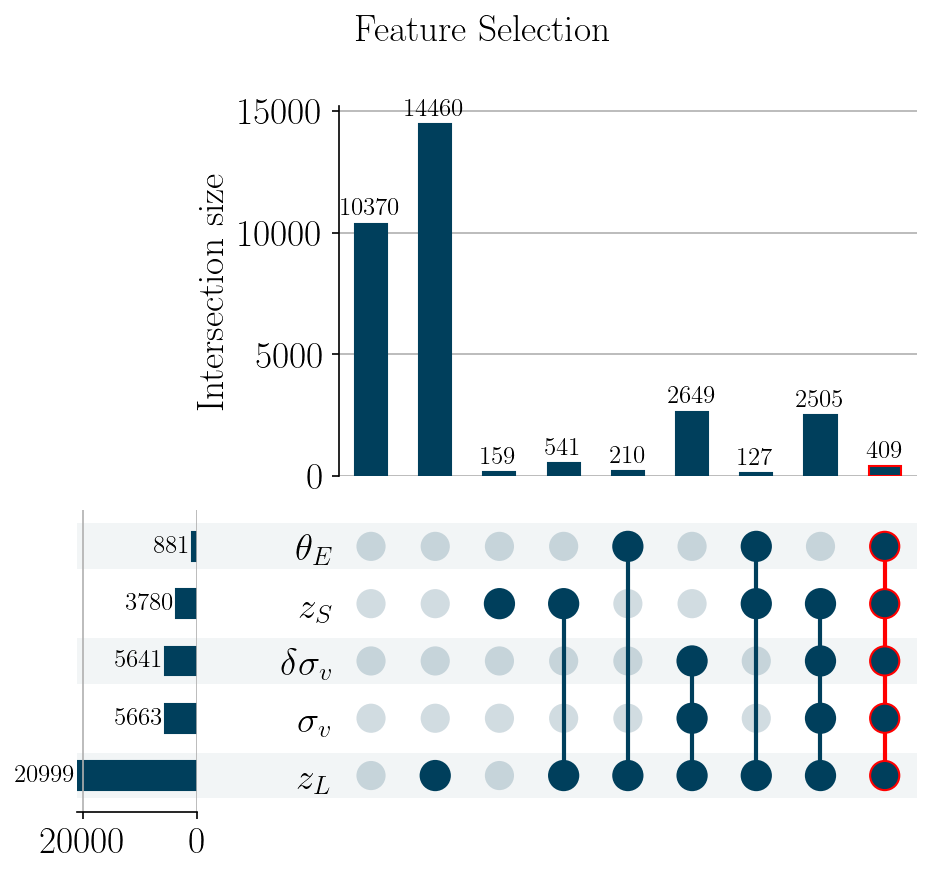

In [8]:
fig = plt.figure(figsize=(15, 10), dpi=150)
d = UpSet(
    Stats_Data,
    sort_by="degree",
    subset_size="sum",
    min_subset_size=100,
    sum_over="JNAME",
    show_counts=True,
    facecolor="#003f5c",
    element_size=40,
)
d.style_subsets(present=Stats_Data.index.names, edgecolor="red", linewidth=1)
d.plot(fig=fig)
plt.suptitle("Feature Selection", fontsize=18)
plt.xlabel("Feature Selection", fontsize=18)
# plt.savefig("graphics/feature_cuts.png", dpi=300, bbox_inches=None)
plt.show()

/home/renan/miniforge3/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/renan/miniforge3/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

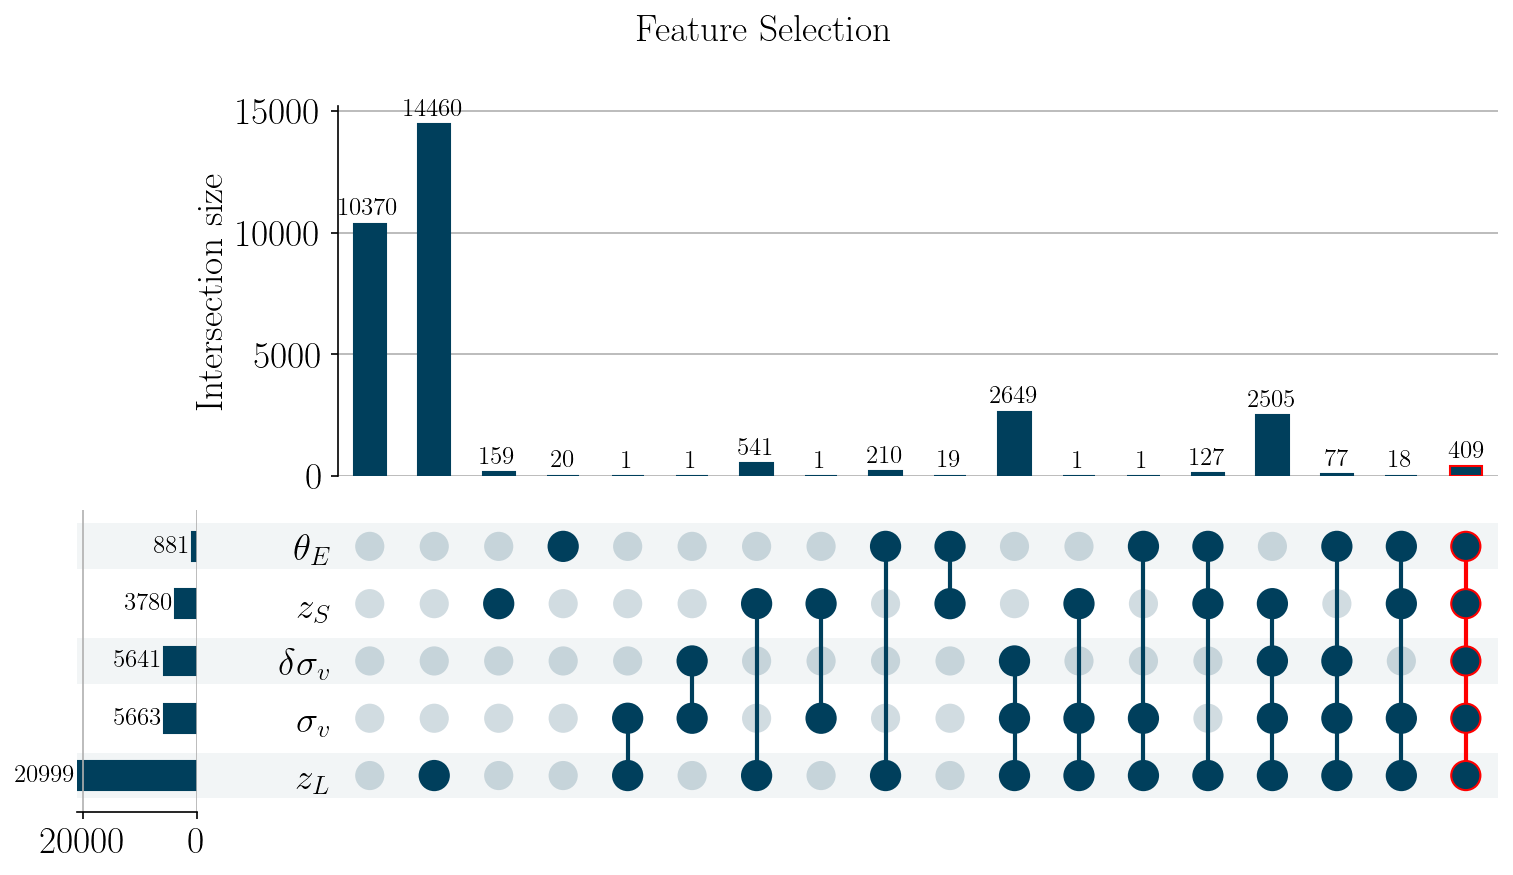

In [9]:
fig = plt.figure(figsize=(15, 10), dpi=150)
d = UpSet(
    Stats_Data,
    sort_by="degree",
    subset_size="sum",
    sum_over="JNAME",
    show_counts=True,
    facecolor="#003f5c",
    element_size=40,
)
d.style_subsets(present=Stats_Data.index.names, edgecolor="red", linewidth=1)
d.plot(fig=fig)
plt.suptitle("Feature Selection", fontsize=18)
plt.xlabel("Feature Selection", fontsize=18)
# plt.savefig("graphics/feature_cuts_thesis.png", dpi=300, bbox_inches=None)
plt.show()

In [10]:
# !convert -trim graphics/feature_cuts_thesis.png graphics/feature_cuts_thesis.png

In [11]:
# !convert -trim graphics/feature_cuts.png graphics/feature_cuts.png

## Show all data:

In [12]:
from upsetplot import from_contents

# Read cutouts
cutouts = pd.read_parquet(io.BytesIO(client.get_object("slcomp", "Cutouts/FITS.parquet").data))
d = (
    cutouts.query('cutout_size=="20asec"')[["JNAME", "survey"]]
    .query('survey!="SDSS"')
    .drop_duplicates(keep="first")
    .groupby(["survey"])
    .agg(list)
    .to_dict()["JNAME"]
)
data = from_contents(d)

matplotlib.rcParams.update({"font.size": 24})

/home/renan/miniforge3/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


/home/renan/miniforge3/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/renan/miniforge3/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

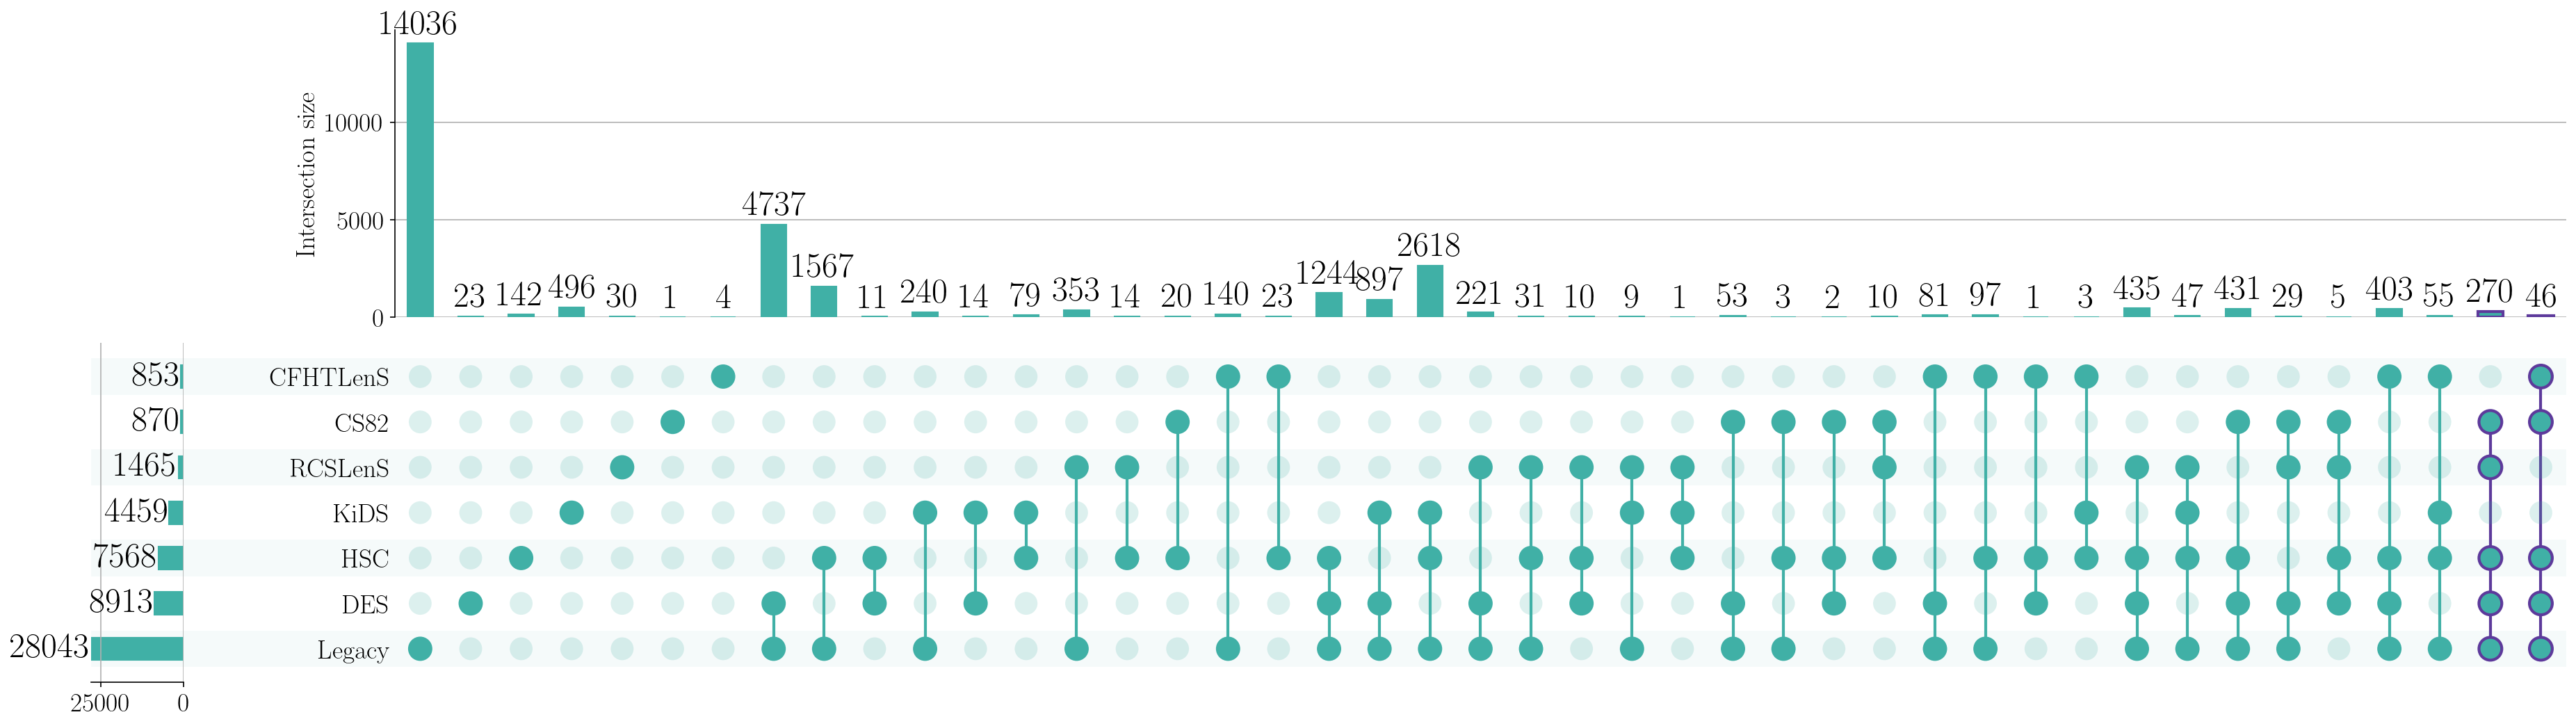

In [13]:
fig = plt.figure(figsize=(40, 17), dpi=150)
d = UpSet(
    data,
    sort_by="degree",
    subset_size="count",
    show_counts=True,
    facecolor="#40B0A6",
    element_size=45,
    orientation="horizontal",
)
d.style_subsets(
    present=["CFHTLenS", "CS82", "DES", "HSC", "Legacy"],
    edgecolor="#5D3A9B",
    linewidth=2,
)
d.style_subsets(
    present=["CS82", "DES", "HSC", "Legacy", "RCSLenS"],
    edgecolor="#5D3A9B",
    linewidth=2,
)
d.plot(fig=fig)
# plt.savefig("graphics/feature_cuts_surveys_all.png", dpi=300, bbox_inches=None)
plt.show()

In [14]:
# !convert -trim graphics/feature_cuts_surveys_all.png graphics/feature_cuts_surveys_all.png

# 3. Only `SDSS` data

Because we need later the seeing/aperture size, and it will be easy to retrieve this information later

In [15]:
Data = (
    Data.query('velDispRef == "SDSS DR17"')
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)
len(Data)

352

# 4. Cleaning lens type

Removing any kind of system that were previously classified as cluster, groups of galaxies, `Non Single Lens Galaxy` and `Non Single Lens Galaxy Merged`:

In [16]:
Data.Lens_Type.unique(), Data.System_Type.unique()

(<StringArray>
 [<NA>, 'GALAXY', 'QUASAR', 'GROUP', 'CLUSTER']
 Length: 5, dtype: string,
 <StringArray>
 [                           <NA>,            'Single Lens Galaxy',
         'Non Single Lens Galaxy', 'Non Single Lens Galaxy Merged']
 Length: 4, dtype: string)

In [17]:
# Initially we considered only Lens Type, but in this time we will restrict our analysis for Non Single Lens galaxy systems.
Data = Data.query(
    '~Lens_Type.isin(["GROUP", "CLUSTER"]) and ~System_Type.isin(["Non Single Lens Galaxy", "Non Single Lens Galaxy Merged"])'
).reset_index(drop=True)
len(Data)

331

# 5. Remove Late-Type galaxies

Late Type Galaxies might have an impact on the value of  $\sigma_v$, for example (merger). Early-Type galaxies are suitable for this kind of test we want to perform. We should remove for now galaxies that are in the SWELLS sample (this sample contains only late type galaxies):

In [18]:
Data = Data[
    ~Data.JNAME.isin(Database[Database.Reference.str.contains("Treu")].JNAME.values)
].reset_index(drop=True)
len(Data)

316

# 6. Get spectra info

In this section we obtain the fiber radius based on the instrument responsible to obtain the spectra information we used and observational seeing:

In [19]:
Spectra = pd.read_csv(io.StringIO((client.get_object("slcomp", "Data/Spectroscopic_Match.csv").data).decode("utf-8")))
Spectra = Spectra[Spectra.JNAME.isin(Data.JNAME)].reset_index(drop=True)
len(Spectra)

316

In [20]:
def fiber_rad(x):
    if "BOSS" in x:
        return 1
    elif "SDSS" in x:
        return 1.5
    else:
        return "Bug"

In [21]:
Spectra["theta_ap"] = Spectra.instrument.apply(fiber_rad)

In [22]:
def get_value(x):
    if " § " in x:
        x = x.split(" § ")
        x = np.hstack(np.array(x))
        x = x[x != "nan"]
        return int(float(x))
    else:
        return int(float(x))

In [23]:
Spectra.fiberid = Spectra.fiberid.apply(get_value)
Spectra.mjd = Spectra.mjd.apply(get_value)
Spectra.plate = Spectra.plate.apply(get_value)

/tmp/ipykernel_577523/2523328443.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(float(x))


In [24]:
Spectra = Spectra[["JNAME", "fiberid", "mjd", "plate", "theta_ap"]]

In [25]:
Data = Data.merge(Spectra, on="JNAME")
len(Data)

316

To obtain the seeing information (https://www.sdss.org/dr17/algorithms/spectro_seeing/), we had to look into each plate files. Also,  check [this page](http://skyserver.sdss.org/dr17/MoreTools/browser?table=platex) for more information. We submitted the following SQL query:

```sql
    SELECT p.plate,p.mjd,p.isPrimary,p.seeing20,p.seeing50,p.seeing80
    FROM platex AS p
    WHERE p.isPrimary = 1
```

in [this page](http://skyserver.sdss.org/dr17/SearchTools/sql).

In [26]:
query_output = pd.read_csv("data/Skyserver_SQL7_13_2022 2_43_17 PM.csv", skiprows=1)
# isPrimary = 1 is this plateX entry both good and the best observation of the plate
query_output = query_output.query("isPrimary == 1").reset_index(drop=True)
print(len(query_output))
query_output.iloc[0:3]

6460


,plate,mjd,isPrimary,seeing20,seeing50,seeing80
0,266,51630,1,1.7300,1.8100,1.8975
1,267,51608,1,1.7350,1.8575,1.9800
2,268,51633,1,1.5325,1.6125,1.6950


In [27]:
Data = Data.merge(query_output, on=["plate", "mjd"]).reset_index(drop=True)
len(Data)

305

Before we look for outliers, let's see the common values for $\sigma_v$ based on the consolidated data (based only in SDSS DR17 data):

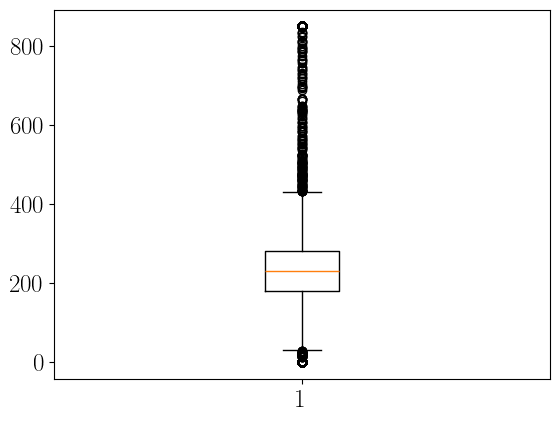

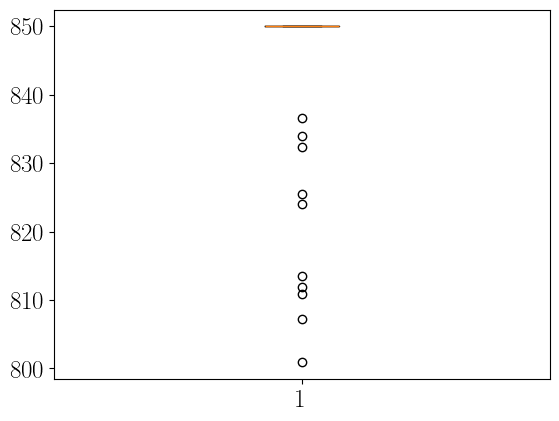

In [28]:
velDisp = Database_C.query('velDispRef=="SDSS DR17"').velDisp.astype(float)

plt.boxplot(velDisp)
plt.show()

plt.boxplot(velDisp[velDisp > 800])
plt.show()

In which we see that $\sigma_v=850$ is an outlier, thus these values should be removed.

8


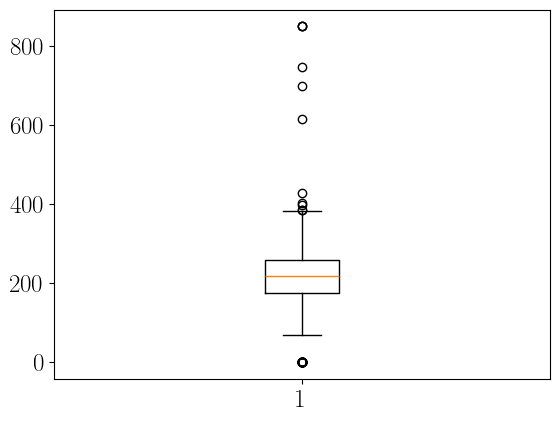

In [29]:
print(sum(Data.velDisp.astype(float) > 400))
p = Data.velDisp.astype(float)
plt.boxplot(p)
plt.show()

Removing wrong values for $\sigma_v$ and observational seeing:

In [30]:
Data[['seeing20', 'seeing50', 'seeing80', 'velDisp']] = Data[['seeing20', 'seeing50', 'seeing80', 'velDisp']].apply(pd.to_numeric)

In [31]:
Data = Data.query(
    "seeing20 != 0 and seeing50 != 0 and seeing80 != 0 and velDisp != 0 and velDisp != 850"
).reset_index(drop=True)
len(Data)

245

# 7. Adding photometric info

Another way to test $\gamma_{\mathrm{PPN}}$ is using the effective radius, assuming a system radius. In order to obtain $\sigma_0$, we need the effective radius $\theta_{\mathrm{eff}}$, which can be obtained from SDSS. The three choices for the system radius presented in SDSS database are the exponential, de Vaucouleurs and Petrosian radius. For reference, we always use the radius in the r band.

In [32]:
Photo = pd.read_csv(io.StringIO((client.get_object("slcomp", "Data/Photometric_Match.csv").data).decode("utf-8")))
Photo = Photo[Photo.JNAME.isin(Data.JNAME)].reset_index(drop=True)
len(Photo)

245

In [33]:
Photo.keys()

Index(['JNAME', 'RA', 'DEC', 'Matching_Index', 'Catalog_Name', 'Survey_ID',
       'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_uErr', 'mag_gErr',
       'mag_rErr', 'mag_iErr', 'mag_zErr', 'devrad_u', 'devrad_g', 'devrad_r',
       'devrad_i', 'devrad_z', 'devraderr_u', 'devraderr_g', 'devraderr_r',
       'devraderr_i', 'devraderr_z', 'exprad_u', 'exprad_g', 'exprad_r',
       'exprad_i', 'exprad_z', 'expraderr_u', 'expraderr_g', 'expraderr_r',
       'expraderr_i', 'expraderr_z', 'petror50_u', 'petror50_g', 'petror50_r',
       'petror50_i', 'petror50_z', 'petror50err_u', 'petror50err_g',
       'petror50err_r', 'petror50err_i', 'petror50err_z', 'Photo-z_L',
       'Photo-z_LErr', 'galdepth_g', 'galdepth_r', 'galdepth_z', 'brickname',
       'Spec-z_L', 'mag_y', 'mag_yErr', 'tilename', 'System_ID', 'object_id',
       'Photo-z_LRisk'],
      dtype='object')

In [34]:
def get_value2(x):
    if type(x) == float:
        return x
    elif " § " in x:
        x = x.split(" § ")
        x = np.hstack(np.array(x))
        x = x[np.where(x != "nan")]
        return float(x)
    else:
        return float(x)

In [35]:
Photo.exprad_r = Photo.exprad_r.apply(get_value2)
Photo.devrad_r = Photo.devrad_r.apply(get_value2)
Photo.petror50_r = Photo.petror50_r.apply(get_value2)

/tmp/ipykernel_577523/1222884193.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x)


In [36]:
Data = Data.merge(Photo[["JNAME", "devrad_r", "exprad_r", "petror50_r"]], on="JNAME")
len(Data)

245

In [37]:
Data.keys()

Index(['JNAME', 'RA', 'DEC', 'System_Type', 'Lens_Type', 'Source_Type',
       'theta_E', 'theta_EErr', 'theta_EMethod', 'theta_ERef', 'z_L', 'z_LErr',
       'z_LType', 'z_LRef', 'velDisp', 'velDispErr', 'velDispRef', 'z_S',
       'z_SErr', 'z_SType', 'z_SRef', 'mag_u', 'mag_uErr', 'mag_uRef',
       'mag_uS', 'mag_uSRef', 'mag_g', 'mag_gErr', 'mag_gRef', 'mag_gS',
       'mag_gSRef', 'mag_r', 'mag_rErr', 'mag_rRef', 'mag_rS', 'mag_rSRef',
       'mag_i', 'mag_iErr', 'mag_iRef', 'mag_iS', 'mag_iSRef', 'mag_z',
       'mag_zErr', 'mag_zRef', 'mag_zS', 'mag_zSRef', 'mag_F814W',
       'mag_F814WErr', 'mag_F814WRef', 'mag_F814WS', 'mag_F814WSRef',
       'fiberid', 'mjd', 'plate', 'theta_ap', 'isPrimary', 'seeing20',
       'seeing50', 'seeing80', 'devrad_r', 'exprad_r', 'petror50_r'],
      dtype='object')

In [38]:
Data = Data[
    [
        "JNAME",
        "RA",
        "DEC",
        "System_Type",
        "Lens_Type",
        "Source_Type",
        "theta_E",
        "theta_EErr",
        "theta_EMethod",
        "theta_ERef",
        "z_L",
        "z_LErr",
        "z_LType",
        "z_LRef",
        "z_S",
        "z_SErr",
        "z_SType",
        "z_SRef",
        "velDisp",
        "velDispErr",
        "velDispRef",
        "mag_u",
        "mag_uErr",
        "mag_uRef",
        "mag_uS",
        "mag_uSRef",
        "mag_g",
        "mag_gErr",
        "mag_gRef",
        "mag_gS",
        "mag_gSRef",
        "mag_r",
        "mag_rErr",
        "mag_rRef",
        "mag_rS",
        "mag_rSRef",
        "mag_i",
        "mag_iErr",
        "mag_iRef",
        "mag_iS",
        "mag_iSRef",
        "mag_z",
        "mag_zErr",
        "mag_zRef",
        "mag_zS",
        "mag_zSRef",
        "mag_F814W",
        "mag_F814WErr",
        "mag_F814WRef",
        "mag_F814WS",
        "mag_F814WSRef",
        "fiberid",
        "mjd",
        "plate",
        "theta_ap",
        "seeing20",
        "seeing50",
        "seeing80",
        "devrad_r",
        "exprad_r",
        "petror50_r",
    ]
].convert_dtypes()

In [39]:
Data.describe()

,velDisp,fiberid,mjd,plate,theta_ap,seeing20,seeing50,seeing80,devrad_r,exprad_r,petror50_r
count,245.0,245.0,245.0,245.0,245.0,245.0,245.0,245.0,243.0,243.0,243.0
mean,238.34106,432.742857,54651.383673,3604.689796,1.204082,1.513188,1.635243,1.787144,1.923659,1.159147,1.703452
std,76.93087,255.385074,1679.743057,2283.827219,0.24625,0.321736,0.354426,0.401223,0.997115,0.458507,0.663681
min,68.74223,5.0,51637.0,274.0,1.0,0.87,0.95,1.05,0.302893,0.326608,0.655836
25%,196.87993,211.0,52932.0,1349.0,1.0,1.26617,1.37,1.4771,1.225528,0.849187,1.219221
50%,231.21548,405.0,55365.0,3973.0,1.0,1.5123,1.61912,1.75456,1.735894,1.075488,1.587253
75%,267.2193,606.0,56034.0,5314.0,1.5,1.71378,1.84975,2.0153,2.435644,1.396349,2.037865
max,747.9916,998.0,58396.0,11316.0,1.5,2.6925,3.02,3.6775,6.373206,3.576023,4.477787


# 8. Removing NaN's (if any)

In [40]:
len(Data), Data.shape

(245, (245, 61))

In [41]:
Data = Data.dropna(axis=1, how="all")
Data = Data.dropna(
    subset=[
        "z_L",
        "z_S",
        "theta_E",
        "velDisp",
        "velDispErr",
        "seeing20",
        "seeing50",
        "seeing80",
        "theta_ap",
        "devrad_r",
        "exprad_r",
        "petror50_r",
    ],
    axis=0,
)

In [42]:
len(Data), Data.shape

(243, (243, 59))

- Converting variables to radians:

In [43]:
Data[['theta_E', 'theta_ap', 'seeing20', 'seeing50', 'seeing80', 'exprad_r', 'devrad_r', 'petror50_r']] = Data[['theta_E', 'theta_ap', 'seeing20', 'seeing50', 'seeing80', 'exprad_r', 'devrad_r', 'petror50_r']].apply(pd.to_numeric)

In [44]:
Data["theta_E_rad"] = Data["theta_E"] * u.arcsec.to(u.rad)
Data["theta_ap_rad"] = Data["theta_ap"] * u.arcsec.to(u.rad)
Data["seeing20_rad"] = Data["seeing20"] * u.arcsec.to(u.rad)
Data["seeing50_rad"] = Data["seeing50"] * u.arcsec.to(u.rad)
Data["seeing80_rad"] = Data["seeing80"] * u.arcsec.to(u.rad)
Data["exprad_r_rad"] = Data["exprad_r"] * u.arcsec.to(u.rad)
Data["devrad_r_rad"] = Data["devrad_r"] * u.arcsec.to(u.rad)
Data["petror50_r_rad"] = Data["petror50_r"] * u.arcsec.to(u.rad)

# 9. Effective radius

In [45]:
Data["velDisp0_exp"] = Data["velDisp"] * (
    (Data["exprad_r_rad"] / (2 * Data["theta_ap_rad"])) ** (-0.066)
)
Data["velDisp0_dev"] = Data["velDisp"] * (
    (Data["devrad_r_rad"] / (2 * Data["theta_ap_rad"])) ** (-0.066)
)
Data["velDisp0_petro"] = Data["velDisp"] * (
    (Data["petror50_r_rad"] / (2 * Data["theta_ap_rad"])) ** (-0.066)
)

In [46]:
@np.vectorize
def cal_velDispErr(velDisp, velDispErr, theta_eff, theta_ap, velDisp0):
    term_1 = (velDispErr**2) / (velDisp**2)
    term_2 = 0.03**2
    term_3 = (np.log(theta_eff / (2 * theta_ap)) * 0.033) ** 2
    return np.sqrt((term_1 + term_2 + term_3) * velDisp0**2)

In [47]:
Data[['velDispErr']] = Data[['velDispErr']].apply(pd.to_numeric)

In [48]:
Data["velDisp0Err_exp"] = cal_velDispErr(
    Data["velDisp"],
    Data["velDispErr"],
    Data["exprad_r_rad"],
    Data["theta_ap_rad"],
    Data["velDisp0_exp"],
)
Data["velDisp0Err_dev"] = cal_velDispErr(
    Data["velDisp"],
    Data["velDispErr"],
    Data["devrad_r_rad"],
    Data["theta_ap_rad"],
    Data["velDisp0_dev"],
)
Data["velDisp0Err_petro"] = cal_velDispErr(
    Data["velDisp"],
    Data["velDispErr"],
    Data["petror50_r_rad"],
    Data["theta_ap_rad"],
    Data["velDisp0_petro"],
)

# 10. Obtain cutouts

In this section of the notebook, we aim to obtain cutouts for each object in the database and visually select early-type galaxies based on certain criteria. These criteria include:

- A score of 3 is assigned to galaxies that appear to be isolated early-type systems without any neighboring objects that could interfere with the measurement of $\sigma_v$ and do not belong to any cluster or group.
- A score of 2 is assigned to systems that might belong to a cluster or have substructure, appear to be late-type galaxies, and have neighboring objects with similar colors.
- A score of 1 is assigned to systems that cannot be classified (for internal use).

In the first round of classification, images from surveys with higher resolution (in the photometric scale) were presented, and the aforementioned scores were assigned. In case of any errors in the image, a score of 1 was given. In the second classification round, all available combined images captured for all surveys were presented. In this case, some information might be more useful and highlighted in one survey than in others.

After the two classification rounds using `lensrater`, systems classified as 3-3 were kept, and systems classified as 2-2 were discarded.

In [49]:
Cutouts = pd.read_parquet(io.BytesIO(client.get_object("slcomp", "Cutouts/Processed_Cutouts.parquet").data))
Cutouts.iloc[0:3]

,JNAME,survey,cutout_size,processing,is_rgb,file_name,file_path
0,J000001.1-350334.9,DES,20asec,lsb,True,J000001.1-350334.9.jpeg,Processed_Cutouts_Legacy/20asec/DES/J000001.1-...
1,J000001.1-350334.9,Legacy,20asec,trilogy,False,J000001.1-350334.9_legacysurvey-0001m350-image...,Processed_Cutouts/20asec/Legacy/J000001.1-3503...
2,J000001.1-350334.9,Legacy,20asec,trilogy,False,J000001.1-350334.9_legacysurvey-0001m350-image...,Processed_Cutouts/20asec/Legacy/J000001.1-3503...


In [50]:
Cutouts = Cutouts[Cutouts.JNAME.isin(Data.JNAME)].reset_index(drop=True)
Cutouts = Cutouts[
    ((Cutouts.survey == "CS82") | (Cutouts.is_rgb == "True"))
    & (Cutouts.cutout_size == "20asec")
].reset_index(drop=True)

In [51]:
len(Data), len(Cutouts.JNAME.unique())

(243, 243)

Get mosaics for all cutouts of the same object:

In [52]:
cutouts = Cutouts
jnames = Cutouts.JNAME.unique()

In [53]:
def get_cutouts(i):
    jname = jnames[i]
    data = cutouts[cutouts.JNAME == jname].reset_index(drop=True)

    nrow = 1
    ncol = len(data)

    fig = plt.figure(figsize=(2 * (ncol + 1), 2 * (nrow + 1)))  # (ncol+1, nrow+1))

    gs = gridspec.GridSpec(
        nrow,
        ncol,
        wspace=0.0,
        hspace=0.0,
        top=1.0 - 0.5 / (nrow + 1),
        bottom=0.5 / (nrow + 1),
        left=0.5 / (ncol + 1),
        right=1 - 0.5 / (ncol + 1),
    )

    k = 0
    for i in range(nrow):
        for j in range(ncol):
            test = data.iloc[k]
            file_name = test.file_name
            if ".png" in file_name:
                survey_tag = f"T: {test.survey}"
            elif ".jpeg" in file_name:
                survey_tag = f"LSB: {test.survey}"

            im = plt.imread(test.file_path)
            ax = plt.subplot(gs[i, j])
            if test.survey == "CS82":
                ax.imshow(im, interpolation="lanczos", aspect="auto", cmap="gray")
            else:
                ax.imshow(im, interpolation="lanczos", aspect="auto")
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])

            left, width = 0.05, 0.5
            bottom, height = 0.05, 0.5

            ax.text(
                left,
                bottom,
                survey_tag,
                horizontalalignment="left",
                verticalalignment="bottom",
                transform=ax.transAxes,
                color="gold",
                fontsize=8,
            )
            k += 1

    # plt.show()
    dir_name = f"images/20_asec_full/"
    os.makedirs(dir_name, exist_ok=True)
    plt.savefig(dir_name + f"/{jname}.png", dpi=300, transparent=True)
    plt.close()

    im = Image.open(dir_name + f"/{jname}.png")
    im2 = im.crop(im.getbbox())
    im2.save(dir_name + f"/{jname}.png")

In [54]:
# args = range(len(jnames))
# result = pqdm(args, get_cutouts, n_jobs=35)

"Best" $20^{\prime\prime}$ image:

In [55]:
def get_cutouts_small(i):
    jname = jnames[i]
    data = cutouts[cutouts.JNAME == jname].reset_index(drop=True)
    data["Survey"] = pd.Categorical(
        data["survey"],
        ["HSC", "RCSLenS", "DES", "CFHTLenS", "CS82", "Legacy", "KiDS", "SDSS"],
    )
    survey = data.sort_values(["survey"])["survey"].unique()[0]
    data = data[data.survey == survey].reset_index(drop=True)

    nrow = 1
    ncol = len(data)

    fig = plt.figure(figsize=(2 * (ncol + 1), 2 * (nrow + 1)))  # (ncol+1, nrow+1))

    gs = gridspec.GridSpec(
        nrow,
        ncol,
        wspace=0.0,
        hspace=0.0,
        top=1.0 - 0.5 / (nrow + 1),
        bottom=0.5 / (nrow + 1),
        left=0.5 / (ncol + 1),
        right=1 - 0.5 / (ncol + 1),
    )

    k = 0
    for i in range(nrow):
        for j in range(ncol):
            test = data.iloc[k]
            file_name = test.file_name
            if ".png" in file_name:
                survey_tag = f"T: {test.survey}"
            elif ".jpeg" in file_name:
                survey_tag = f"LSB: {test.survey}"

            im = plt.imread(test.file_path)
            ax = plt.subplot(gs[i, j])
            if test.survey == "CS82":
                ax.imshow(im, interpolation="lanczos", aspect="auto", cmap="gray")
            else:
                ax.imshow(im, interpolation="lanczos", aspect="auto")
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])

            left, width = 0.05, 0.5
            bottom, height = 0.05, 0.5

            ax.text(
                left,
                bottom,
                survey_tag,
                horizontalalignment="left",
                verticalalignment="bottom",
                transform=ax.transAxes,
                color="gold",
                fontsize=8,
            )
            k += 1

    # plt.show()
    dir_name = f"images/20_asec_best/"
    os.makedirs(dir_name, exist_ok=True)
    plt.savefig(dir_name + f"/{jname}.png", dpi=300, transparent=True)
    plt.close()

    im = Image.open(dir_name + f"/{jname}.png")
    im2 = im.crop(im.getbbox())
    im2.save(dir_name + f"/{jname}.png")

In [56]:
# args = range(len(jnames))
# result = pqdm(args, get_cutouts_small, n_jobs=35)

# 11. Performing visual inspection

For this task, we used [lensrater](https://github.com/oliveirara/lensrater) to classify all objects. After each visual inspection, we get a `csv` file containing all scores.

# 12. Visual inspection round and Final Sample

In [57]:
visual_inspection_1 = pd.read_csv("images/20_asec_best/scores.csv")
visual_inspection_2 = pd.read_csv("images/20_asec_full/scores.csv")

In [58]:
len(visual_inspection_1), len(visual_inspection_2)

(243, 243)

In [59]:
data_inspection = pd.merge(visual_inspection_1, visual_inspection_2, on="image")
data_inspection.head()

,username_x,image,score_x,username_y,score_y
0,renan,J000408.1+141150.7.png,3,renan,3
1,renan,J001016.4+175852.2.png,3,renan,3
2,renan,J001321.4+114039.6.png,3,renan,3
3,renan,J002123.2-042926.2.png,3,renan,3
4,renan,J002240.9+143110.1.png,3,renan,3


In [60]:
(
    data_inspection.score_x.unique(),
    data_inspection.score_y.unique(),
)

(array([3, 2, 1]), array([3, 2]))

In [61]:
both_agree = data_inspection[
    (data_inspection.score_x == 3) & (data_inspection.score_y == 3)
]
both_agree.score_x.unique(), both_agree.score_y.unique()

(array([3]), array([3]))

In [62]:
len(data_inspection)  # total objects

243

In [63]:
len(both_agree)  # objects classified as 3

183

In [64]:
len(
    data_inspection[(data_inspection.score_x == 2) & (data_inspection.score_y == 2)]
)  # discarted objects

30

In [65]:
243 - 183 - 30

30

There are 31 systems that raised some doubts, i.e., from first and second classification rounds, e.g., 3-2, 2-3, 1-3, 1-2:

In [66]:
data_re_inspection = data_inspection[
    ((data_inspection.score_x == 3) & (data_inspection.score_y == 2))
    | ((data_inspection.score_x == 2) & (data_inspection.score_y == 3))
    | ((data_inspection.score_x == 1) & (data_inspection.score_y == 3))
    | ((data_inspection.score_x == 1) & (data_inspection.score_y == 2))
]
len(data_re_inspection)

30

In [67]:
# for image in data_re_inspection.image:
#     shutil.copy("images/20_asec_full/" + image, "images/20_asec_full_re_check/" + image)

In [68]:
visual_inspection_3 = pd.read_csv("images/20_asec_full_re_check/scores.csv")
len(visual_inspection_3[visual_inspection_3.score == 3])

23

In [69]:
jnames = [
    image.split(".png")[0]
    for image in np.hstack(
        (both_agree.image, visual_inspection_3[visual_inspection_3.score == 3].image)
    )
]
len(jnames)

206

In [70]:
Data["vis_inspec"] = Data.JNAME.isin(jnames)

In [71]:
sum(Data.vis_inspec)

206

The sample containing `vis_inspec==True` is dubbed `LaStBeRu_cosmo_ground` and will be the sample we'll use in the next notebooks.

# 13. Saving the data

In [72]:
Data.keys()

Index(['JNAME', 'RA', 'DEC', 'System_Type', 'Lens_Type', 'Source_Type',
       'theta_E', 'theta_EErr', 'theta_EMethod', 'theta_ERef', 'z_L', 'z_LErr',
       'z_LType', 'z_LRef', 'z_S', 'z_SErr', 'z_SType', 'z_SRef', 'velDisp',
       'velDispErr', 'velDispRef', 'mag_u', 'mag_uErr', 'mag_uRef', 'mag_uS',
       'mag_uSRef', 'mag_g', 'mag_gErr', 'mag_gRef', 'mag_gS', 'mag_gSRef',
       'mag_r', 'mag_rErr', 'mag_rRef', 'mag_rS', 'mag_rSRef', 'mag_i',
       'mag_iErr', 'mag_iRef', 'mag_iS', 'mag_iSRef', 'mag_z', 'mag_zErr',
       'mag_zRef', 'mag_zS', 'mag_zSRef', 'mag_F814W', 'mag_F814WErr',
       'mag_F814WRef', 'fiberid', 'mjd', 'plate', 'theta_ap', 'seeing20',
       'seeing50', 'seeing80', 'devrad_r', 'exprad_r', 'petror50_r',
       'theta_E_rad', 'theta_ap_rad', 'seeing20_rad', 'seeing50_rad',
       'seeing80_rad', 'exprad_r_rad', 'devrad_r_rad', 'petror50_r_rad',
       'velDisp0_exp', 'velDisp0_dev', 'velDisp0_petro', 'velDisp0Err_exp',
       'velDisp0Err_dev', 'velDisp0Er

In [73]:
Data = Data.query("vis_inspec==True").reset_index(drop=True)

In [74]:
Data = Data[
    [
        "JNAME",
        "RA",
        "DEC",
        "System_Type",
        "Lens_Type",
        "Source_Type",
        "theta_E",
        "theta_E_rad",
        "theta_EErr",
        "theta_EMethod",
        "theta_ERef",
        "z_L",
        "z_LErr",
        "z_LType",
        "z_LRef",
        "z_S",
        "z_SErr",
        "z_SType",
        "z_SRef",
        "velDisp",
        "velDispErr",
        "velDispRef",
        "mag_u",
        "mag_uErr",
        "mag_uRef",
        "mag_uS",
        "mag_uSRef",
        "mag_g",
        "mag_gErr",
        "mag_gRef",
        "mag_gS",
        "mag_gSRef",
        "mag_r",
        "mag_rErr",
        "mag_rRef",
        "mag_rS",
        "mag_rSRef",
        "mag_i",
        "mag_iErr",
        "mag_iRef",
        "mag_iS",
        "mag_iSRef",
        "mag_z",
        "mag_zErr",
        "mag_zRef",
        "mag_zS",
        "mag_zSRef",
        "mag_F814W",
        "mag_F814WErr",
        "mag_F814WRef",
        "fiberid",
        "mjd",
        "plate",
        "theta_ap",
        "theta_ap_rad",
        "seeing20",
        "seeing20_rad",
        "seeing50",
        "seeing50_rad",
        "seeing80",
        "seeing80_rad",
        "devrad_r",
        "exprad_r",
        "petror50_r",
        "devrad_r_rad",
        "exprad_r_rad",
        "petror50_r_rad",
        "velDisp0_dev",
        "velDisp0Err_dev",
        "velDisp0_exp",
        "velDisp0Err_exp",
        "velDisp0_petro",
        "velDisp0Err_petro",
    ]
]

# Data Cleaning

In [75]:
jnames_to_remove = [
    "J082227.5+182855.8", # Late type galaxy
    "J015618.1-010747.1", # Wrong classification theta_E method (label wrong from Master Lens Database)
    "J220506.9+014703.7", # Velocity dispersion from SDSS doesn't match
]

In [76]:
Data = Data.query("~JNAME.isin(@jnames_to_remove)").reset_index(drop=True)

In [77]:
jnames_from_Cao = Data.query("theta_ERef == 'Cao et al. (2020) - arXiv:2008.01361'").JNAME
jnames_from_bellsgallery = Database.query("Other_Matches.str.contains('BELLSGALLERY', na=False)").JNAME
jnames_from_Cao_that_are_not_in_bellsgallery = jnames_from_Cao[~jnames_from_Cao.isin(jnames_from_bellsgallery)]
len(jnames_from_Cao_that_are_not_in_bellsgallery)

71

In [78]:
Data = Data.query("~JNAME.isin(@jnames_from_Cao_that_are_not_in_bellsgallery)").reset_index(drop=True)

In [79]:
Data.to_csv("01_LaStBeRu_cosmo_ground.csv", index=False)